# Semantic Representation Error Analysis

This notebook uses `agent1_semantic_representation_gpt5.5.json` as the **reference semantic structure** to compare the intermediate semantic outputs from Aya, Qwen, and Gemma.

The goal is not only to ask which model scores higher, but to identify which parts of the schema each model struggles with.

```json
{
  "participants": ["speaker names"],
  "semantic_grounding": [
    {
      "event_id": 1,
      "speaker": "speaker name",
      "speech_act": "short label",
      "intended_meaning": "concise interpretation",
      "actor": "person or null",
      "action": "concise action",
      "object": "object or null",
      "recipient": "person or null",
      "evidence": ["short quote"]
    }
  ],
  "final_outcome": "one concise sentence"
}
```

## What This Notebook Measures

| Area | Question | Main Metrics |
|---|---|---|
| Schema validity | Did the model produce usable JSON? | parse error rate |
| Participants | Did it identify dialogue speakers correctly? | precision / recall / F1 |
| Event coverage | Did it capture reference events? | event coverage, omitted event count |
| Event granularity | Did it over/under split events? | event count diff, extra event rate |
| Semantic roles | Did it fill actor/action/object/recipient? | missing / mismatch rates |
| Pragmatic meaning | Did it capture intended meaning and speech act? | text similarity, speech-act category match |
| Evidence | Did it ground events in the right quote? | evidence similarity |
| Final outcome | Did it preserve the concise outcome? | final outcome similarity |
| Downstream quality | Do representation errors explain summary scores? | correlation with Omniscore |


In [1]:
from pathlib import Path
import json
import csv
import re
import difflib
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import linear_sum_assignment
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

pd.set_option('display.max_colwidth', 140)
pd.set_option('display.max_columns', 120)


def find_project_root():
    cwd = Path.cwd().resolve()
    marker = Path('notebooks/evaluation/structures/structures_gpt5.5/agent1_semantic_representation_gpt5.5.json')
    for candidate in [cwd, *cwd.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError('Could not find project root. Run this notebook inside the repository.')

PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / 'notebooks/evaluation/structures/evaluation_outputs/semantic_error_analysis'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REF_PATH = PROJECT_ROOT / 'notebooks/evaluation/structures/structures_gpt5.5/agent1_semantic_representation_gpt5.5.json'
MODEL_PATHS = {
    'aya32b': PROJECT_ROOT / 'notebooks/agents/results/full/semantic/aya/semantic_aya32b_50samples_intermediate.jsonl',
    'qwen27b': PROJECT_ROOT / 'notebooks/agents/results/full/semantic/qwen/semantic_qwen27b_50samples_intermediate.jsonl',
    'gemma27b': PROJECT_ROOT / 'notebooks/agents/results/full/semantic/gemma/semantic_gemma27b_50samples_intermediate.jsonl',
}
EVAL_PATHS = {
    'aya32b': PROJECT_ROOT / 'notebooks/agents/results/full/semantic/aya/eval/semantic_aya32b_50samples_omniscore_per_example.csv',
    'qwen27b': PROJECT_ROOT / 'notebooks/agents/results/full/semantic/qwen/eval/semantic_qwen27b_50samples_omniscore_per_example.csv',
    'gemma27b': PROJECT_ROOT / 'notebooks/agents/results/full/semantic/gemma/eval/semantic_gemma27b_50samples_omniscore_per_example.csv',
}

print(PROJECT_ROOT)
print('SciPy available:', HAS_SCIPY)


/Users/yunu919/Desktop/CLMS/LING573/573ChineseEnglishSummarization
SciPy available: True


## 1. Load Reference, Model Outputs, and Omniscore

The reference file is indexed by `test_index`. Each model output is a JSONL file with the same sample ids. Omniscore is optional but useful for linking representation-level mistakes to downstream summary quality.


In [2]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def load_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_omniscore(path):
    if not path.exists():
        return {}
    scores = {}
    with open(path, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if row.get('mode') == 'source_grounded':
                example_id = int(row['example_id'])
                scores[example_id] = {
                    'informativeness': float(row['informativeness']),
                    'clarity': float(row['clarity']),
                    'plausibility': float(row['plausibility']),
                    'faithfulness': float(row['faithfulness']),
                }
    return scores

reference = {item['test_index']: item for item in load_json(REF_PATH)}
model_outputs = {model: load_jsonl(path) for model, path in MODEL_PATHS.items()}
omniscores = {model: load_omniscore(path) for model, path in EVAL_PATHS.items()}

print('Reference examples:', len(reference))
for model, rows in model_outputs.items():
    print(model, len(rows), 'rows')


Reference examples: 50
aya32b 50 rows
qwen27b 50 rows
gemma27b 50 rows


## 2. Normalization and Similarity Functions

Event labels and `intended_meaning` are free text, so strict exact matching is too brittle. This notebook uses:

- exact/set matching for participants and entity-like slots when appropriate;
- token-F1 + sequence similarity for free-text semantic comparison;
- a small speech-act category mapping to compare labels such as `question`, `inquiry`, and `request` more fairly.

The threshold values are intentionally visible. Adjust them if manual inspection suggests alignments are too strict or too loose.


In [3]:
EVENT_MATCH_THRESHOLD = 0.32
WEAK_MATCH_THRESHOLD = 0.45
SLOT_TEXT_MATCH_THRESHOLD = 0.50


def is_missing(x):
    return x is None or x == '' or x == []


def normalize_entity(x):
    if is_missing(x):
        return None
    x = str(x).lower().strip()
    x = re.sub(r'[^a-z0-9\s]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x or None


def tokens(x):
    return re.findall(r"[a-z0-9']+", str(x or '').lower())


def token_f1(a, b):
    ta, tb = Counter(tokens(a)), Counter(tokens(b))
    if not ta and not tb:
        return 1.0
    if not ta or not tb:
        return 0.0
    overlap = sum((ta & tb).values())
    precision = overlap / sum(tb.values()) if tb else 0.0
    recall = overlap / sum(ta.values()) if ta else 0.0
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def seq_ratio(a, b):
    return difflib.SequenceMatcher(None, str(a or '').lower(), str(b or '').lower()).ratio()


def text_similarity(a, b):
    return 0.65 * token_f1(a, b) + 0.35 * seq_ratio(a, b)


def event_text(event):
    if not isinstance(event, dict):
        return ''
    parts = [
        event.get('speaker'),
        event.get('speech_act'),
        event.get('intended_meaning'),
        event.get('actor'),
        event.get('action'),
        event.get('object'),
        event.get('recipient'),
        ' '.join(event.get('evidence') or []),
    ]
    return ' '.join(str(x) for x in parts if not is_missing(x))


def evidence_text(event):
    return ' '.join(event.get('evidence') or []) if isinstance(event, dict) else ''


def participant_prf(reference_participants, model_participants):
    ref = {normalize_entity(x) for x in (reference_participants or []) if normalize_entity(x)}
    pred = {normalize_entity(x) for x in (model_participants or []) if normalize_entity(x)}
    tp = len(ref & pred)
    precision = tp / len(pred) if pred else (1.0 if not ref else 0.0)
    recall = tp / len(ref) if ref else (1.0 if not pred else 0.0)
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1, sorted(ref - pred), sorted(pred - ref)


def speech_act_category(label):
    label = normalize_entity(label) or ''
    groups = {
        'question_request': ['ask', 'question', 'inquiry', 'request', 'checking', 'clarification'],
        'agreement_confirmation': ['agree', 'agreement', 'confirm', 'confirmation', 'accept', 'acceptance', 'acknowledge'],
        'inform_update': ['inform', 'update', 'statement', 'assertion', 'disclosure', 'reveal', 'report', 'explain', 'notify'],
        'commitment_plan': ['commit', 'promise', 'plan', 'arrange', 'schedule', 'decide', 'offer'],
        'suggestion_invitation': ['suggest', 'proposal', 'propose', 'recommend', 'invitation', 'invite'],
        'refusal_cancel': ['refuse', 'reject', 'decline', 'cancel', 'deny'],
        'emotion_social': ['apology', 'thank', 'greet', 'sympathy', 'reassurance', 'concern', 'compliment'],
    }
    for category, keywords in groups.items():
        if any(keyword in label for keyword in keywords):
            return category
    return 'other'


def slot_match(ref_value, model_value, slot):
    if is_missing(ref_value):
        return np.nan
    if is_missing(model_value):
        return 0.0
    if slot in {'actor', 'recipient', 'speaker'}:
        return float(normalize_entity(ref_value) == normalize_entity(model_value))
    return float(text_similarity(ref_value, model_value) >= SLOT_TEXT_MATCH_THRESHOLD)


## 3. Event Alignment

Reference and model events do not always have the same `event_id`, so we align events by semantic similarity rather than by id. This prevents false errors when a model captures the right event but numbers it differently.

Interpretation:

- **matched event**: model event is similar enough to a reference event;
- **weak match**: aligned but semantically thin or partially wrong;
- **omitted reference event**: reference event has no adequate model counterpart;
- **extra model event**: model produced an event with no reference counterpart, often background or over-segmentation.


In [4]:
def align_events(reference_events, model_events, threshold=EVENT_MATCH_THRESHOLD):
    n_ref, n_model = len(reference_events), len(model_events)
    if n_ref == 0 and n_model == 0:
        return [], [], []
    if n_ref == 0:
        return [], [], list(range(n_model))
    if n_model == 0:
        return [], list(range(n_ref)), []

    sim_matrix = np.zeros((n_ref, n_model))
    for i, ref_event in enumerate(reference_events):
        for j, model_event in enumerate(model_events):
            sim_matrix[i, j] = text_similarity(event_text(ref_event), event_text(model_event))

    if HAS_SCIPY:
        row_ind, col_ind = linear_sum_assignment(-sim_matrix)
        raw_pairs = list(zip(row_ind, col_ind))
    else:
        raw_pairs = []
        used_ref, used_model = set(), set()
        candidates = [(-sim_matrix[i, j], i, j) for i in range(n_ref) for j in range(n_model)]
        for neg_score, i, j in sorted(candidates):
            if i not in used_ref and j not in used_model:
                raw_pairs.append((i, j))
                used_ref.add(i)
                used_model.add(j)

    matches = []
    matched_ref, matched_model = set(), set()
    for i, j in raw_pairs:
        score = float(sim_matrix[i, j])
        if score >= threshold:
            matches.append({'ref_i': int(i), 'model_i': int(j), 'score': score})
            matched_ref.add(int(i))
            matched_model.add(int(j))

    omitted_refs = [i for i in range(n_ref) if i not in matched_ref]
    extra_models = [j for j in range(n_model) if j not in matched_model]
    return matches, omitted_refs, extra_models


## 4. Build Per-Example and Per-Event Error Tables

The main table (`metrics_df`) has one row per model/example. The event table (`event_df`) has one row per aligned event pair and is useful for qualitative inspection.


In [5]:
def analyze_example(model_name, row, reference_item, score_row=None):
    test_index = row.get('test_index')
    semantic = row.get('agent1_semantic_representation') or {}
    base = {
        'model': model_name,
        'test_index': test_index,
        'id': row.get('id'),
        'parse_error': bool(semantic.get('parse_error') or 'semantic_grounding' not in semantic),
        'dialogue': row.get('dialogue'),
        'reference_english_summary': row.get('reference_english_summary'),
        'reference_chinese_summary': row.get('reference_chinese_summary'),
        'model_summary_zh': (row.get('agent2_summary_generation') or {}).get('summary_zh'),
    }
    if score_row:
        base.update(score_row)

    if base['parse_error']:
        base.update({
            'participant_precision': np.nan,
            'participant_recall': np.nan,
            'participant_f1': np.nan,
            'missing_participants': None,
            'extra_participants': None,
            'ref_event_count': len(reference_item.get('semantic_grounding') or []),
            'model_event_count': np.nan,
            'event_count_diff': np.nan,
            'event_coverage': 0.0,
            'extra_event_rate': np.nan,
            'omitted_ref_event_count': len(reference_item.get('semantic_grounding') or []),
            'extra_model_event_count': np.nan,
            'weak_match_count': np.nan,
            'final_outcome_similarity': np.nan,
            'selected_event_count': np.nan,
            'invalid_selected_event_count': np.nan,
            'raw_output_excerpt': str(semantic.get('raw_output', ''))[:500],
        })
        return base, []

    ref_events = reference_item.get('semantic_grounding') or []
    model_events = semantic.get('semantic_grounding') or []
    matches, omitted_refs, extra_models = align_events(ref_events, model_events)

    p, r, f1, missing_participants, extra_participants = participant_prf(
        reference_item.get('participants'), semantic.get('participants')
    )

    selected_events = (row.get('agent2_summary_generation') or {}).get('selected_events') or []
    model_event_ids = {event.get('event_id') for event in model_events}
    invalid_selected = [event for event in selected_events if event.get('event_id') not in model_event_ids]

    slot_scores = defaultdict(list)
    slot_missing = Counter()
    slot_mismatch = Counter()
    speech_act_category_scores = []
    intended_scores = []
    action_scores = []
    evidence_scores = []
    weak_match_count = 0
    event_rows = []

    for match in matches:
        ref_event = ref_events[match['ref_i']]
        model_event = model_events[match['model_i']]
        if match['score'] < WEAK_MATCH_THRESHOLD:
            weak_match_count += 1

        speech_ref = speech_act_category(ref_event.get('speech_act'))
        speech_model = speech_act_category(model_event.get('speech_act'))
        speech_act_category_scores.append(float(speech_ref == speech_model))

        intended_sim = text_similarity(ref_event.get('intended_meaning'), model_event.get('intended_meaning'))
        action_sim = text_similarity(ref_event.get('action'), model_event.get('action'))
        evidence_sim = text_similarity(evidence_text(ref_event), evidence_text(model_event))
        intended_scores.append(intended_sim)
        action_scores.append(action_sim)
        evidence_scores.append(evidence_sim)

        for slot in ['speaker', 'actor', 'action', 'object', 'recipient']:
            score = slot_match(ref_event.get(slot), model_event.get(slot), slot)
            if not np.isnan(score):
                slot_scores[slot].append(score)
                if is_missing(model_event.get(slot)):
                    slot_missing[slot] += 1
                elif score == 0.0:
                    slot_mismatch[slot] += 1

        event_rows.append({
            'model': model_name,
            'test_index': test_index,
            'ref_event_id': ref_event.get('event_id'),
            'model_event_id': model_event.get('event_id'),
            'alignment_score': match['score'],
            'weak_match': match['score'] < WEAK_MATCH_THRESHOLD,
            'ref_speech_act': ref_event.get('speech_act'),
            'model_speech_act': model_event.get('speech_act'),
            'ref_speech_category': speech_ref,
            'model_speech_category': speech_model,
            'ref_intended_meaning': ref_event.get('intended_meaning'),
            'model_intended_meaning': model_event.get('intended_meaning'),
            'ref_actor': ref_event.get('actor'),
            'model_actor': model_event.get('actor'),
            'ref_action': ref_event.get('action'),
            'model_action': model_event.get('action'),
            'ref_object': ref_event.get('object'),
            'model_object': model_event.get('object'),
            'ref_recipient': ref_event.get('recipient'),
            'model_recipient': model_event.get('recipient'),
            'ref_evidence': evidence_text(ref_event),
            'model_evidence': evidence_text(model_event),
            'intended_similarity': intended_sim,
            'action_similarity': action_sim,
            'evidence_similarity': evidence_sim,
        })

    for i in omitted_refs:
        ref_event = ref_events[i]
        event_rows.append({
            'model': model_name,
            'test_index': test_index,
            'error_type': 'omitted_reference_event',
            'ref_event_id': ref_event.get('event_id'),
            'ref_speech_act': ref_event.get('speech_act'),
            'ref_intended_meaning': ref_event.get('intended_meaning'),
            'ref_actor': ref_event.get('actor'),
            'ref_action': ref_event.get('action'),
            'ref_object': ref_event.get('object'),
            'ref_recipient': ref_event.get('recipient'),
            'ref_evidence': evidence_text(ref_event),
        })

    for j in extra_models:
        model_event = model_events[j]
        event_rows.append({
            'model': model_name,
            'test_index': test_index,
            'error_type': 'extra_model_event',
            'model_event_id': model_event.get('event_id'),
            'model_speech_act': model_event.get('speech_act'),
            'model_intended_meaning': model_event.get('intended_meaning'),
            'model_actor': model_event.get('actor'),
            'model_action': model_event.get('action'),
            'model_object': model_event.get('object'),
            'model_recipient': model_event.get('recipient'),
            'model_evidence': evidence_text(model_event),
        })

    ref_count = len(ref_events)
    model_count = len(model_events)
    matched_count = len(matches)

    base.update({
        'participant_precision': p,
        'participant_recall': r,
        'participant_f1': f1,
        'missing_participants': ', '.join(missing_participants),
        'extra_participants': ', '.join(extra_participants),
        'ref_event_count': ref_count,
        'model_event_count': model_count,
        'event_count_diff': model_count - ref_count,
        'event_coverage': matched_count / ref_count if ref_count else 1.0,
        'extra_event_rate': len(extra_models) / model_count if model_count else 0.0,
        'omitted_ref_event_count': len(omitted_refs),
        'extra_model_event_count': len(extra_models),
        'weak_match_count': weak_match_count,
        'speech_act_category_accuracy': np.mean(speech_act_category_scores) if speech_act_category_scores else np.nan,
        'intended_meaning_similarity': np.mean(intended_scores) if intended_scores else np.nan,
        'action_similarity': np.mean(action_scores) if action_scores else np.nan,
        'evidence_similarity': np.mean(evidence_scores) if evidence_scores else np.nan,
        'final_outcome_similarity': text_similarity(reference_item.get('final_outcome'), semantic.get('final_outcome')),
        'selected_event_count': len(selected_events),
        'invalid_selected_event_count': len(invalid_selected),
        'raw_output_excerpt': None,
    })

    for slot in ['speaker', 'actor', 'action', 'object', 'recipient']:
        base[f'{slot}_slot_accuracy'] = np.mean(slot_scores[slot]) if slot_scores[slot] else np.nan
        base[f'{slot}_missing_count'] = slot_missing[slot]
        base[f'{slot}_mismatch_count'] = slot_mismatch[slot]

    # Direct null rates over the model output, independent of reference alignment.
    for slot in ['speaker', 'speech_act', 'intended_meaning', 'actor', 'action', 'object', 'recipient', 'evidence']:
        values = [event.get(slot) for event in model_events]
        base[f'{slot}_null_rate'] = np.mean([is_missing(v) for v in values]) if values else np.nan

    return base, event_rows


all_metrics = []
all_event_rows = []

for model_name, rows in model_outputs.items():
    score_lookup = omniscores.get(model_name, {})
    for row in rows:
        test_index = row['test_index']
        if test_index not in reference:
            print('Missing reference:', model_name, test_index)
            continue
        metrics_row, event_rows = analyze_example(
            model_name,
            row,
            reference[test_index],
            score_lookup.get(test_index),
        )
        all_metrics.append(metrics_row)
        all_event_rows.extend(event_rows)

metrics_df = pd.DataFrame(all_metrics)
event_df = pd.DataFrame(all_event_rows)

metrics_df.to_csv(OUTPUT_DIR / 'semantic_model_error_metrics_per_example.csv', index=False)
event_df.to_csv(OUTPUT_DIR / 'semantic_model_event_alignment_details.csv', index=False)

print(metrics_df.shape)
print(event_df.shape)
metrics_df.head()


(150, 56)
(674, 26)


,model,test_index,id,parse_error,dialogue,reference_english_summary,reference_chinese_summary,model_summary_zh,informativeness,clarity,plausibility,faithfulness,participant_precision,participant_recall,participant_f1,missing_participants,extra_participants,ref_event_count,model_event_count,event_count_diff,event_coverage,extra_event_rate,omitted_ref_event_count,extra_model_event_count,weak_match_count,speech_act_category_accuracy,intended_meaning_similarity,action_similarity,evidence_similarity,final_outcome_similarity,selected_event_count,invalid_selected_event_count,raw_output_excerpt,speaker_slot_accuracy,speaker_missing_count,speaker_mismatch_count,actor_slot_accuracy,actor_missing_count,actor_mismatch_count,action_slot_accuracy,action_missing_count,action_mismatch_count,object_slot_accuracy,object_missing_count,object_mismatch_count,recipient_slot_accuracy,recipient_missing_count,recipient_mismatch_count,speaker_null_rate,speech_act_null_rate,intended_meaning_null_rate,actor_null_rate,action_null_rate,object_null_rate,recipient_null_rate,evidence_null_rate
0,aya32b,23,gold_00001,False,"Anne: You were right, he was lying to me :/\nIrene: Oh no, what happened?\nJane: who? that Mark guy?\nAnne: yeah, he told me he's 30, to...",Mark lied to Anne about his age. Mark is 40.,马克向安妮隐瞒了自己的年龄。他40岁了。,安妮发现马克撒了关于年龄的谎，并和艾琳及简讨论了此事。艾琳对谎言的重要性表示怀疑。,2.854782,3.359607,3.525179,2.705961,1.0,1.0,1.0,,,1,5.0,4.0,1.000000,0.800000,0,4.0,0.0,0.0,0.660360,0.110526,0.273333,0.505831,2.0,0.0,None,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.600000,0.0
1,aya32b,30,gold_00002,False,"Mary: hey, im kinda broke, lend me a few box\r\nCarter: okay, give me an hour, im at the train station\r\nMary: cool, thanks",Mary ran out of money. Carter is going to lend her some in an hour.,玛丽的钱用完了，卡特打算一小时后借给她一点。,玛丽请求卡特借钱，卡特同意在一小时后借给她几盒钱。,2.515700,4.594635,4.465599,3.338059,1.0,1.0,1.0,,,2,3.0,1.0,1.000000,0.333333,0,1.0,0.0,0.5,0.685640,0.341667,0.934722,0.756031,1.0,0.0,None,1.0,0.0,0.0,0.5,0.0,1.0,0.5,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.333333,0.0
2,aya32b,39,gold_00003,False,"Tina: I'll tell you something, this Emirate staff looks amazing, as movie stars\r\nAla: Oh yes, I know, that's for purpose \r\nAla: It's...",Tina will catch the evening flight back home. Ala is on her way to the meeting. She will let Tina know how it went.,蒂娜将乘晚间航班回家。阿拉正在去开会的路上。她会让蒂娜知道事情的进展。,蒂娜抱怨旅行遭遇，阿拉同情并提及即将举行的会议，蒂娜要求告知会议结果。,3.549798,3.640035,3.760340,3.018245,1.0,1.0,1.0,,,3,6.0,3.0,0.666667,0.666667,1,4.0,1.0,0.5,0.404709,0.396125,0.388216,0.295968,3.0,0.0,None,0.5,0.0,1.0,1.0,0.0,0.0,0.5,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.500000,0.500000,0.500000,0.666667,0.0
3,aya32b,65,gold_00004,False,Ana: You sleeping?\r\nCatherine: Not yet.\r\nAna: Wanna go visit grandma tomorrow? I miss her.\r\nCatherine: Yeah that would be nice :) ...,Ana wants to visit grandma tomorrow. Catherine will go with her. She will call Anna when she wakes up.,安娜明天想去看望奶奶。凯瑟琳会和她一起去。她起床后会给安娜打电话。,安娜和凯瑟琳计划次日拜访祖母，凯瑟琳醒后会给安娜打电话。,1.565261,4.667234,4.555789,3.592227,1.0,1.0,1.0,,,3,4.0,1.0,0.666667,0.500000,1,2.0,0.0,0.5,0.245218,0.813889,0.754914,0.495147,1.0,0.0,None,1.0,0.0,0.0,0.5,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.750000,0.500000,0.500000,0.500000,0.0
4,aya32b,66,gold_00005,False,Joyce: Check this out!\r\nJoyce: <link>\r\nMichael: That's cheap!\r\nEdson: No way! I'm booking my ticket now!!,Edson is booking his ticket now.,埃德森正在订票。,乔伊斯分享了廉价机票的链接，迈克尔表达了惊讶，艾德森决定立即预订机票。,2.135915,4.876489,4.861402,4.232075,1.0,1.0,1.0,,,2,3.0,1.0,1.000000,0.333333,0,1.0,0.0,1.0,0.644530,0.396122,0.923253,0.495996,1.0,0.0,None,1.0,0.0,0.0,0.5,1.0,0.0,0.5,0.0,1.0,0.5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.666667,0.333333,0.666667,0.666667,0.0


## 5. Model-Level Error Profile

This table is the best first result to put into a report. It turns many low-level comparisons into interpretable model profiles.

Helpful reading:

- high `parse_error_rate` means output-format instability;
- high `event_count_diff_mean` and `extra_event_rate_mean` indicate over-segmentation or background event inclusion;
- low `event_coverage_mean` indicates missing core events;
- high slot null rates indicate weak semantic role filling;
- low `final_outcome_similarity_mean` indicates the representation drifts away from the reference conclusion.


In [6]:
summary_spec = {
    'parse_error': 'mean',
    'participant_f1': 'mean',
    'event_coverage': 'mean',
    'extra_event_rate': 'mean',
    'event_count_diff': 'mean',
    'omitted_ref_event_count': 'mean',
    'extra_model_event_count': 'mean',
    'weak_match_count': 'mean',
    'speech_act_category_accuracy': 'mean',
    'intended_meaning_similarity': 'mean',
    'action_similarity': 'mean',
    'evidence_similarity': 'mean',
    'final_outcome_similarity': 'mean',
    'actor_null_rate': 'mean',
    'action_null_rate': 'mean',
    'object_null_rate': 'mean',
    'recipient_null_rate': 'mean',
    'selected_event_count': 'mean',
    'invalid_selected_event_count': 'sum',
    'informativeness': 'mean',
    'clarity': 'mean',
    'plausibility': 'mean',
    'faithfulness': 'mean',
}

summary_df = metrics_df.groupby('model').agg(summary_spec).reset_index()
summary_df = summary_df.rename(columns={
    'parse_error': 'parse_error_rate',
    'event_count_diff': 'event_count_diff_mean',
})
summary_df.to_csv(OUTPUT_DIR / 'semantic_model_error_summary_by_model.csv', index=False)
summary_df.round(3)


,model,parse_error_rate,participant_f1,event_coverage,extra_event_rate,event_count_diff_mean,omitted_ref_event_count,extra_model_event_count,weak_match_count,speech_act_category_accuracy,intended_meaning_similarity,action_similarity,evidence_similarity,final_outcome_similarity,actor_null_rate,action_null_rate,object_null_rate,recipient_null_rate,selected_event_count,invalid_selected_event_count,informativeness,clarity,plausibility,faithfulness
0,aya32b,0.02,1.000,0.849,0.458,1.939,0.58,2.429,0.367,0.616,0.453,0.234,0.828,0.481,0.592,0.356,0.332,0.240,1.592,0.0,2.691,3.669,3.767,3.023
1,gemma27b,0.12,0.989,0.677,0.249,0.182,1.06,0.955,0.205,0.669,0.529,0.450,0.813,0.523,0.223,0.000,0.267,0.257,2.068,1.0,2.537,3.677,3.791,3.118
2,qwen27b,0.00,0.993,0.821,0.271,0.360,0.66,1.020,0.320,0.682,0.543,0.446,0.829,0.485,0.045,0.000,0.154,0.315,2.420,0.0,2.632,3.691,3.810,3.135


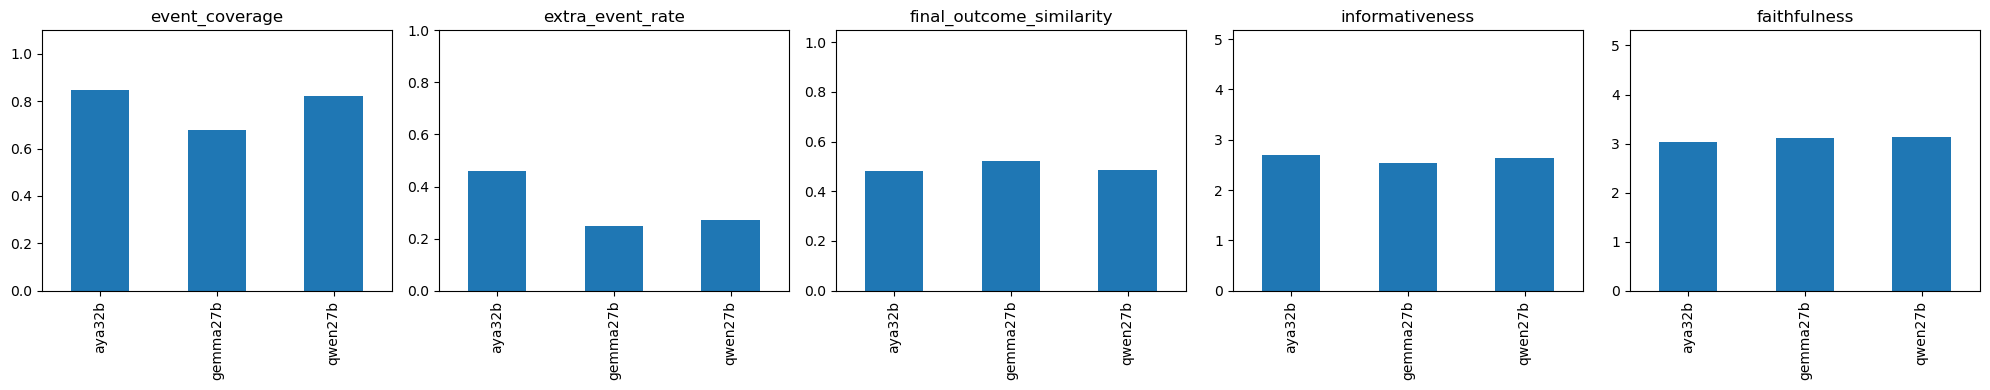

In [7]:
plot_cols = [
    'event_coverage',
    'extra_event_rate',
    'final_outcome_similarity',
    'informativeness',
    'faithfulness',
]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 4), sharey=False)
for ax, col in zip(axes, plot_cols):
    metrics_df.groupby('model')[col].mean().sort_index().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylim(0, max(1.0, metrics_df[col].max(skipna=True) * 1.1))
plt.tight_layout()
plt.show()


## 6. Error Type Counts

This view is useful for statements like:

- “Aya tends to over-segment dialogue turns into extra semantic events.”
- “Gemma has more schema/parse instability.”
- “Qwen is structurally stable but still misses or mis-prioritizes some core events.”


In [8]:
error_counts = []
for model, group in metrics_df.groupby('model'):
    valid = group[~group['parse_error']]
    error_counts.append({
        'model': model,
        'n': len(group),
        'parse_errors': int(group['parse_error'].sum()),
        'participant_mismatch_examples': int(((valid['participant_f1'] < 1.0).fillna(False)).sum()),
        'over_segmented_examples': int((valid['event_count_diff'] > 0).sum()),
        'under_segmented_examples': int((valid['event_count_diff'] < 0).sum()),
        'examples_with_omitted_events': int((valid['omitted_ref_event_count'] > 0).sum()),
        'examples_with_extra_events': int((valid['extra_model_event_count'] > 0).sum()),
        'low_final_outcome_examples': int((valid['final_outcome_similarity'] < 0.35).sum()),
        'low_informativeness_examples': int((valid['informativeness'] < 2.2).sum()) if 'informativeness' in valid else np.nan,
    })

error_counts_df = pd.DataFrame(error_counts)
error_counts_df.to_csv(OUTPUT_DIR / 'semantic_model_error_type_counts.csv', index=False)
error_counts_df


,model,n,parse_errors,participant_mismatch_examples,over_segmented_examples,under_segmented_examples,examples_with_omitted_events,examples_with_extra_events,low_final_outcome_examples,low_informativeness_examples
0,aya32b,50,1,0,44,0,20,48,11,11
1,gemma27b,50,6,2,15,10,25,28,7,11
2,qwen27b,50,0,1,22,6,22,36,9,10


## 7. Slot-Level Weaknesses

This section separates two problems:

1. **Null rate**: the model did not fill the field at all.
2. **Alignment slot accuracy**: when a reference event was matched to a model event, did the slot agree with the reference?

For example, high `actor_null_rate` suggests the model is not extracting semantic roles well. Low `action_slot_accuracy` suggests the action is present but semantically different or too vague.


In [9]:
slot_cols = []
for slot in ['speaker', 'actor', 'action', 'object', 'recipient']:
    slot_cols.extend([f'{slot}_slot_accuracy', f'{slot}_missing_count', f'{slot}_mismatch_count'])
for slot in ['actor', 'action', 'object', 'recipient']:
    slot_cols.append(f'{slot}_null_rate')

slot_summary = metrics_df.groupby('model')[slot_cols].mean().round(3)
slot_summary.to_csv(OUTPUT_DIR / 'semantic_model_slot_summary.csv')
slot_summary


,speaker_slot_accuracy,speaker_missing_count,speaker_mismatch_count,actor_slot_accuracy,actor_missing_count,actor_mismatch_count,action_slot_accuracy,action_missing_count,action_mismatch_count,object_slot_accuracy,object_missing_count,object_mismatch_count,recipient_slot_accuracy,recipient_missing_count,recipient_mismatch_count,actor_null_rate,action_null_rate,object_null_rate,recipient_null_rate
model,,,,,,,,,,,,,,,,,,,
aya32b,0.957,0.0,0.122,0.315,1.347,0.429,0.179,0.694,1.592,0.507,0.429,0.776,0.500,0.102,0.367,0.592,0.356,0.332,0.240
gemma27b,0.992,0.0,0.023,0.615,0.500,0.568,0.433,0.000,1.500,0.493,0.477,0.659,0.654,0.068,0.250,0.223,0.000,0.267,0.257
qwen27b,0.987,0.0,0.040,0.727,0.120,0.680,0.424,0.000,1.580,0.690,0.200,0.620,0.859,0.020,0.080,0.045,0.000,0.154,0.315


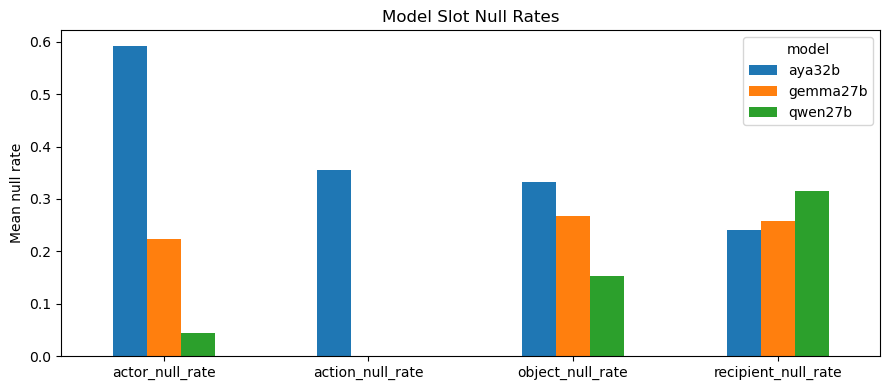

In [10]:
null_rate_cols = ['actor_null_rate', 'action_null_rate', 'object_null_rate', 'recipient_null_rate']
metrics_df.groupby('model')[null_rate_cols].mean().T.plot(kind='bar', figsize=(9, 4))
plt.title('Model Slot Null Rates')
plt.ylabel('Mean null rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Link Representation Errors to Omniscore

This correlation table helps argue that representation-level mistakes matter downstream. Useful expected patterns:

- lower `event_coverage` should correlate with lower `informativeness`;
- higher `extra_event_rate` can correlate with lower informativeness or clarity if background events distract the summary;
- lower `final_outcome_similarity` often tracks lower informativeness/faithfulness.

With only 50 samples, treat correlations as diagnostic rather than definitive statistical proof.


In [11]:
correlation_cols = [
    'participant_f1',
    'event_coverage',
    'extra_event_rate',
    'event_count_diff',
    'omitted_ref_event_count',
    'extra_model_event_count',
    'speech_act_category_accuracy',
    'intended_meaning_similarity',
    'action_similarity',
    'evidence_similarity',
    'final_outcome_similarity',
    'actor_null_rate',
    'action_null_rate',
    'object_null_rate',
    'recipient_null_rate',
    'selected_event_count',
]
score_cols = ['informativeness', 'clarity', 'plausibility', 'faithfulness']

corr_rows = []
for model, group in metrics_df[~metrics_df['parse_error']].groupby('model'):
    for metric in correlation_cols:
        for score in score_cols:
            if metric in group and score in group:
                corr = group[[metric, score]].corr(method='spearman').iloc[0, 1]
                corr_rows.append({'model': model, 'metric': metric, 'score': score, 'spearman_corr': corr})

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(OUTPUT_DIR / 'semantic_error_omniscore_correlations.csv', index=False)

corr_pivot = corr_df.pivot_table(index=['model', 'metric'], columns='score', values='spearman_corr')
corr_pivot.round(3).sort_index()


score                                  clarity  faithfulness  informativeness  \
model    metric                                                                 
aya32b   action_null_rate               -0.041        -0.121           -0.199   
         action_similarity               0.300         0.164           -0.099   
         actor_null_rate                -0.179        -0.134           -0.033   
         event_count_diff               -0.099         0.123            0.485   
         event_coverage                 -0.007        -0.147            0.009   
         evidence_similarity            -0.057        -0.193           -0.294   
         extra_event_rate               -0.148         0.113            0.299   
         extra_model_event_count        -0.140         0.161            0.475   
         final_outcome_similarity        0.010        -0.379           -0.376   
         intended_meaning_similarity     0.127         0.190            0.091   
         object_null_rate                0.001         0.004           -0.062   
         omitted_ref_event_count        -0.033         0.116            0.009   
         recipient_null_rate             0.057        -0.080           -0.168   
         selected_event_count            0.025        -0.046            0.086   
         speech_act_category_accuracy    0.236        -0.029           -0.300   
gemma27b action_similarity               0.156         0.111           -0.158   
         actor_null_rate                -0.010        -0.018            0.130   
         event_count_diff                0.013         0.098            0.289   
         event_coverage                  0.017         0.215            0.262   
         evidence_similarity             0.117         0.073           -0.192   
         extra_event_rate               -0.046        -0.043            0.099   
         extra_model_event_count        -0.044        -0.048            0.142   
         final_outcome_similarity        0.303         0.004           -0.118   
         intended_meaning_similarity     0.159         0.346            0.168   
         object_null_rate                0.086         0.105            0.397   
         omitted_ref_event_count        -0.045        -0.185           -0.227   
         participant_f1                 -0.104         0.113            0.168   
         recipient_null_rate            -0.182         0.112            0.432   
         selected_event_count           -0.080         0.034            0.282   
         speech_act_category_accuracy   -0.001         0.094            0.065   
qwen27b  action_similarity               0.204         0.134           -0.133   
         actor_null_rate                -0.310        -0.173            0.171   
         event_count_diff               -0.342        -0.189            0.398   
         event_coverage                 -0.061         0.096            0.293   
         evidence_similarity             0.018         0.008           -0.176   
         extra_event_rate               -0.230        -0.312           -0.054   
         extra_model_event_count        -0.263        -0.334            0.078   
         final_outcome_similarity        0.278         0.158            0.022   
         intended_meaning_similarity     0.240         0.250            0.003   
         object_null_rate               -0.008        -0.066           -0.147   
         omitted_ref_event_count         0.066        -0.095           -0.277   
         participant_f1                 -0.124         0.124            0.243   
         recipient_null_rate            -0.261        -0.272           -0.049   
         selected_event_count            0.190        -0.008            0.053   
         speech_act_category_accuracy   -0.069        -0.028           -0.028   

score                                  plausibility  
model    metric                                      
aya32b   action_null_rate                    -0.064  
         action_similarity    

## 9. Worst-Case Tables for Qualitative Analysis

Quantitative metrics are only convincing if paired with concrete examples. The tables below surface examples worth reading manually.


In [12]:
def top_cases(model=None, sort_by='informativeness', ascending=True, n=8, cols=None):
    df = metrics_df.copy()
    if model:
        df = df[df['model'] == model]
    if cols is None:
        cols = [
            'model', 'test_index', sort_by, 'faithfulness', 'event_coverage', 'extra_event_rate',
            'event_count_diff', 'omitted_ref_event_count', 'extra_model_event_count',
            'final_outcome_similarity', 'reference_english_summary', 'model_summary_zh'
        ]
    return df.sort_values(sort_by, ascending=ascending)[cols].head(n)

print('Lowest informativeness cases')
display(top_cases(sort_by='informativeness', ascending=True, n=10))

print('Lowest event coverage cases')
display(top_cases(sort_by='event_coverage', ascending=True, n=10))

print('Highest extra event rate cases')
display(top_cases(sort_by='extra_event_rate', ascending=False, n=10))


Lowest informativeness cases


,model,test_index,informativeness,faithfulness,event_coverage,extra_event_rate,event_count_diff,omitted_ref_event_count,extra_model_event_count,final_outcome_similarity,reference_english_summary,model_summary_zh
90,qwen27b,635,1.207506,2.622906,0.600000,0.400000,0.0,2,2.0,0.545407,"Gloria and Mell plan to have a barbeque at Mell's place on Saturday. They are happy, because Tad's sister moved to Scotland. Mell needs ...",梅尔和格洛里亚商定本周六在梅尔家举办烧烤，梅尔负责准备食物，格洛里亚负责饮料和甜点。
140,gemma27b,635,1.207506,2.622906,0.600000,0.400000,0.0,2,2.0,0.473249,"Gloria and Mell plan to have a barbeque at Mell's place on Saturday. They are happy, because Tad's sister moved to Scotland. Mell needs ...",梅尔和格洛丽亚决定在本周六在梅尔家举办烧烤，梅尔准备食物，格洛丽亚负责饮品和甜点。
40,aya32b,635,1.207506,2.622906,0.000000,NaN,NaN,5,NaN,NaN,"Gloria and Mell plan to have a barbeque at Mell's place on Saturday. They are happy, because Tad's sister moved to Scotland. Mell needs ...",Mell和Gloria聊天，讨论了孩子们搬出去后的生活变化。Mell坦白自己有时会忘记想念孩子们，但喜欢现在的平静。Gloria安慰她，并邀请她家里开烧烤派对。Mell欣然接受，并建议在周末举行。Gloria确认日期为下周六。
122,gemma27b,393,1.243417,1.266065,0.000000,NaN,NaN,2,NaN,NaN,Marika is coming today.,None
72,qwen27b,393,1.353611,1.394436,1.000000,0.000000,0.0,0,0.0,0.485000,Marika is coming today.,玛丽卡询问劳拉今天是否出席，劳拉确认会来。
33,aya32b,548,1.381526,2.055603,1.000000,0.250000,1.0,0,1.0,0.544668,"Steve and Rob will talk about new Dream Theater album, after they finish listening.",史蒂夫和罗布计划稍后互相分享他们对新梦剧院专辑的意见。
22,aya32b,393,1.512029,1.507673,1.000000,0.333333,1.0,0,1.0,0.436364,Marika is coming today.,玛丽卡问劳拉今天是否来，劳拉确认她会出席，玛丽卡表示高兴。
102,gemma27b,39,1.538569,2.914543,0.333333,0.500000,-1.0,2,1.0,0.507333,Tina will catch the evening flight back home. Ala is on her way to the meeting. She will let Tina know how it went.,蒂娜的航班延误。阿拉承诺向蒂娜汇报会议结果。
45,aya32b,711,1.542520,1.449099,0.666667,0.600000,2.0,1,3.0,0.392587,Alex prefers the Flash to Barman and Superman thanks to his speed.,Pedro询问Alex对蝙蝠侠和超人的偏好，但Alex表示更喜欢闪电侠，并解释了闪电侠的能力。Pedro最终承认了Alex的观点。
3,aya32b,65,1.565261,3.592227,0.666667,0.500000,1.0,1,2.0,0.495147,Ana wants to visit grandma tomorrow. Catherine will go with her. She will call Anna when she wakes up.,安娜和凯瑟琳计划次日拜访祖母，凯瑟琳醒后会给安娜打电话。


Lowest event coverage cases


,model,test_index,event_coverage,faithfulness,event_coverage,extra_event_rate,event_count_diff,omitted_ref_event_count,extra_model_event_count,final_outcome_similarity,reference_english_summary,model_summary_zh
115,gemma27b,215,0.000000,2.380332,0.000000,NaN,NaN,6,NaN,NaN,"Freddie, Kelly, Jim, Greg, Bob, Mike, Mary, Alan and Nancy are watching different shows on Netflix.",None
114,gemma27b,212,0.000000,2.803007,0.000000,NaN,NaN,3,NaN,NaN,Nathan and Aaron are discussing a video which Nathan sent.,None
122,gemma27b,393,0.000000,1.266065,0.000000,NaN,NaN,2,NaN,NaN,Marika is coming today.,None
136,gemma27b,598,0.000000,3.071630,0.000000,NaN,NaN,3,NaN,NaN,A sweet little black cat got into the pitch during the Everton's football match.,None
130,gemma27b,536,0.000000,2.092237,0.000000,NaN,NaN,3,NaN,NaN,Christie and Katie are tired after the party. They both had fun.,None
104,gemma27b,66,0.000000,4.731358,0.000000,NaN,NaN,2,NaN,NaN,Edson is booking his ticket now.,None
40,aya32b,635,0.000000,2.622906,0.000000,NaN,NaN,5,NaN,NaN,"Gloria and Mell plan to have a barbeque at Mell's place on Saturday. They are happy, because Tad's sister moved to Scotland. Mell needs ...",Mell和Gloria聊天，讨论了孩子们搬出去后的生活变化。Mell坦白自己有时会忘记想念孩子们，但喜欢现在的平静。Gloria安慰她，并邀请她家里开烧烤派对。Mell欣然接受，并建议在周末举行。Gloria确认日期为下周六。
133,gemma27b,548,0.000000,2.387770,0.000000,0.0,-3.0,3,0.0,0.597101,"Steve and Rob will talk about new Dream Theater album, after they finish listening.",史蒂夫和罗布都获得了新的梦剧场专辑，并将稍后分享他们的看法。
65,qwen27b,215,0.166667,2.630533,0.166667,0.8,-1.0,5,4.0,0.194776,"Freddie, Kelly, Jim, Greg, Bob, Mike, Mary, Alan and Nancy are watching different shows on Netflix.",弗雷迪向凯利推荐《古战场传奇》或《都铎王朝》，凯利拒绝了鲍勃推荐的《格林》或《萨布丽娜》，迈克则建议格雷格观看《白宫风云》。
89,qwen27b,621,0.250000,2.378933,0.250000,0.5,-2.0,3,1.0,0.446236,"Phil received a card from Deana. Constantine was happy. Phil has sunglasses, that Deana found in the back above the radio. Deana and Phi...",迪安娜将太阳镜送给菲尔，菲尔同意收下并负责保管。


Highest extra event rate cases


,model,test_index,extra_event_rate,faithfulness,event_coverage,extra_event_rate,event_count_diff,omitted_ref_event_count,extra_model_event_count,final_outcome_similarity,reference_english_summary,model_summary_zh
0,aya32b,23,0.800000,2.705961,1.000000,0.800000,4.0,0,4.0,0.505831,Mark lied to Anne about his age. Mark is 40.,安妮发现马克撒了关于年龄的谎，并和艾琳及简讨论了此事。艾琳对谎言的重要性表示怀疑。
65,qwen27b,215,0.800000,2.630533,0.166667,0.800000,-1.0,5,4.0,0.194776,"Freddie, Kelly, Jim, Greg, Bob, Mike, Mary, Alan and Nancy are watching different shows on Netflix.",弗雷迪向凯利推荐《古战场传奇》或《都铎王朝》，凯利拒绝了鲍勃推荐的《格林》或《萨布丽娜》，迈克则建议格雷格观看《白宫风云》。
125,gemma27b,433,0.750000,2.621566,0.500000,0.750000,2.0,1,3.0,0.635341,Sam appreciates the hotel owned by Jessica and Michael. Sam is going there on the 15th August at around 2pm.,萨姆和同伴将于八月十五日下午两点抵达迈克尔和杰西卡的酒店。
50,qwen27b,23,0.666667,2.690091,1.000000,0.666667,2.0,0,2.0,0.443424,Mark lied to Anne about his age. Mark is 40.,安妮揭露马克谎报年龄，他自称三十岁实则四十岁。尽管艾琳质疑此事的重要性，安妮仍坚持认为这种欺骗是严重的背叛。
16,aya32b,244,0.666667,3.968512,0.666667,0.666667,3.0,1,4.0,0.751120,Jones and Angelina will meet in town in the afternoon.,琼斯和安吉丽娜计划在镇上的下午见面，具体地点由琼斯电话确认。
75,qwen27b,433,0.666667,3.097974,0.500000,0.666667,1.0,1,2.0,0.436748,Sam appreciates the hotel owned by Jessica and Michael. Sam is going there on the 15th August at around 2pm.,迈克尔确认酒店预订已安排，并与萨姆最终确定抵达时间为8月15日下午2点。
11,aya32b,192,0.666667,2.978752,0.666667,0.666667,3.0,1,4.0,0.300142,"Harris' friend, Aoki, who lives in Michigan, died yesterday. Harris hasn't seen her for a few months.",哈里斯向莱娜透露了朋友青木的死讯，莱娜给予安慰并认同生命的不可预测性。哈里斯最终结束了对话，称母亲在叫他。
6,aya32b,78,0.666667,3.955403,0.666667,0.666667,3.0,1,4.0,0.282839,Fiona wants to prepare dinner for Chris. She is thinking of Tina's tart. She will help her make it.,菲奥娜请求蒂娜帮助制作馅饼，蒂娜同意并提供了避免炒鸡蛋的技巧，指导馅料制作。
43,aya32b,678,0.666667,3.977995,0.666667,0.666667,3.0,1,4.0,0.282172,Kate and Jeff are downstairs in a room next to the reception. Some lady is making a marzipan cake.,萨姆询问凯特的位置，凯特邀请他下来并分享了一个带有巨大阴茎的蛋糕的观察结果。萨姆对这个蛋糕表现出浓厚的兴趣，渴望一睹其风采。
2,aya32b,39,0.666667,3.018245,0.666667,0.666667,3.0,1,4.0,0.295968,Tina will catch the evening flight back home. Ala is on her way to the meeting. She will let Tina know how it went.,蒂娜抱怨旅行遭遇，阿拉同情并提及即将举行的会议，蒂娜要求告知会议结果。


## 10. Case Explorer

Use this function to inspect individual examples. It prints reference events, model events, omitted events, extra events, aligned pairs, and the final generated Chinese summary.


In [13]:
def get_model_row(model, test_index):
    rows = [row for row in model_outputs[model] if row['test_index'] == test_index]
    if not rows:
        raise KeyError((model, test_index))
    return rows[0]


def print_event(event, prefix=''):
    fields = ['event_id', 'speaker', 'speech_act', 'intended_meaning', 'actor', 'action', 'object', 'recipient', 'evidence']
    for field in fields:
        print(f'{prefix}{field}: {event.get(field)}')


def show_case(model, test_index):
    row = get_model_row(model, test_index)
    ref = reference[test_index]
    semantic = row.get('agent1_semantic_representation') or {}
    metric_row = metrics_df[(metrics_df['model'] == model) & (metrics_df['test_index'] == test_index)].iloc[0]

    print('=' * 100)
    print(f'MODEL: {model} | test_index: {test_index}')
    print('=' * 100)
    print('\nDIALOGUE')
    print(row.get('dialogue'))
    print('\nREFERENCE ENGLISH SUMMARY')
    print(row.get('reference_english_summary'))
    print('\nREFERENCE CHINESE SUMMARY')
    print(row.get('reference_chinese_summary'))
    print('\nMODEL SUMMARY ZH')
    print((row.get('agent2_summary_generation') or {}).get('summary_zh'))
    print('\nMETRICS')
    display(metric_row[[
        'parse_error', 'participant_f1', 'event_coverage', 'extra_event_rate', 'event_count_diff',
        'omitted_ref_event_count', 'extra_model_event_count', 'final_outcome_similarity',
        'informativeness', 'faithfulness'
    ]])

    if metric_row['parse_error']:
        print('\nPARSE ERROR RAW OUTPUT EXCERPT')
        print(semantic.get('raw_output', '')[:1500])
        return

    ref_events = ref.get('semantic_grounding') or []
    model_events = semantic.get('semantic_grounding') or []
    matches, omitted_refs, extra_models = align_events(ref_events, model_events)

    print('\nREFERENCE FINAL OUTCOME')
    print(ref.get('final_outcome'))
    print('\nMODEL FINAL OUTCOME')
    print(semantic.get('final_outcome'))

    print('\nALIGNED EVENTS')
    for match in matches:
        print('-' * 80)
        print(f"alignment_score={match['score']:.3f}")
        print('REF:')
        print_event(ref_events[match['ref_i']], prefix='  ')
        print('MODEL:')
        print_event(model_events[match['model_i']], prefix='  ')

    print('\nOMITTED REFERENCE EVENTS')
    for i in omitted_refs:
        print('-' * 80)
        print_event(ref_events[i], prefix='  ')

    print('\nEXTRA MODEL EVENTS')
    for j in extra_models:
        print('-' * 80)
        print_event(model_events[j], prefix='  ')

# Example:
# show_case('aya32b', 23)
# show_case('qwen27b', 215)
# show_case('gemma27b', 39)


## 11. Suggested Reporting Template

After running the notebook, use the generated CSV files in:

`notebooks/evaluation/structures/evaluation_outputs/semantic_error_analysis/`

Recommended report structure:

1. **Reference setup**  
   State that `agent1_semantic_representation_gpt5.5.json` is used as a GPT-derived semantic reference, not as an unquestionable human gold annotation.

2. **Model-level comparison**  
   Use `semantic_model_error_summary_by_model.csv` and `semantic_model_error_type_counts.csv`.

3. **Error taxonomy**  
   Analyze errors under participants, event coverage, event granularity, semantic roles, evidence grounding, and final outcome.

4. **Model-specific profiles**  
   - Aya: likely over-segmentation and weak role filling.
   - Qwen: likely strongest schema stability, but salience/topic abstraction errors.
   - Gemma: likely compact outputs but more parse errors and omitted core events.

5. **Qualitative examples**  
   Use `show_case(model, test_index)` for 2-3 representative examples per model.

6. **Downstream link**  
   Use correlation results to discuss how representation errors relate to low `informativeness`, `faithfulness`, or both.
